# BasicTask6
EnKFを実装し、KFと比較する。Whitaker and Hamill (2002)によるSerial EnSRF, Bishop et al. (2001)によるETKF、Hunt et al. (2007)によるLETKF、PO法などの解法がある。2つ以上実装すること。

## Lorenz96モデルの実装

In [1]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    Lorenz96モデルの微分方程式を定義する関数
    x: 状態変数の配列
    F: 外部からの強制力
    """
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
    return dxdt
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]

def make_homogeneous_H(n, p):
    """
    p x n の均等観測演算子 H を作成する。
    観測は状態ベクトル長 n の要素から均等間隔で p 個を選ぶ（重複しないよう int に丸める）。
    戻り値:
      H : ndarray, shape (p, n)  -- 観測演算子（選んだ要素に対応する行が単位ベクトル）
      indices : ndarray, shape (p,) -- 観測に使う状態インデックス（0-based）
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    # 均等にインデックスを決める（端点を含める）
    indices = np.linspace(0, n - 1, p, dtype=int)
    # インデックスが重複する場合は調整（微小ずらし）
    # （通常は p<=n なら重複は起きにくいが念のため）
    uniq, counts = np.unique(indices, return_counts=True)
    if uniq.size != indices.size:
        # 重複を解消する簡易処理：採用済みインデックスを避けつつ前方に埋める
        used = set()
        new_idx = []
        for v in indices:
            if v in used:
                # 前後を探索して未使用インデックスを探す
                left = v - 1
                right = v + 1
                found = None
                while left >= 0 or right < n:
                    if left >= 0 and left not in used:
                        found = left
                        break
                    if right < n and right not in used:
                        found = right
                        break
                    left -= 1
                    right += 1
                if found is None:
                    raise RuntimeError("Cannot resolve duplicate observation indices")
                new_idx.append(found)
                used.add(found)
            else:
                new_idx.append(int(v))
                used.add(int(v))
        indices = np.array(new_idx, dtype=int)
    H = np.zeros((p, n), dtype=float)
    for i, idx in enumerate(indices):
        H[i, idx] = 1.0
    return H

def make_dense_H(n, p, dense=False, random_scale=0.01, seed=None):
    """
    n: 状態次元
    p: 観測次元
    dense: True にすると、(i,i)=1 に加えて残りの要素を小さい乱数で埋める（"dense" 化）
    random_scale: dense=True のときの乱数標準偏差
    seed: 乱数シード（再現性が欲しいときに指定）
    戻り値:
      H: ndarray, shape (p, n)
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    H = np.zeros((p, n), dtype=float)
    # 最初の p 行について対角成分 (i,i) を 1 にする
    for i in range(p):
        H[i, i] = 1.0

    if dense:
        rng = np.random.default_rng(seed)
        # 対角の位置は上書きしないようマスクを作る
        mask = np.ones((p, n), dtype=bool)
        for i in range(p):
            mask[i, i] = False
        H[mask] = rng.normal(loc=0.0, scale=random_scale, size=mask.sum())

    return H

## EnKFの実装

### PO法

In [3]:
# PO法でEnKFを実装するクラス
class EnKF_PO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0):
        """
        EnKFをPO法で初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.R = R if R is not None else np.eye(N, N) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # シード値を固定して再現性を確保
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def forecast(self):
        """
        アンサンブルの予報ステップを実行するメソッド
        """
        if self.ensemble is None:
            raise RuntimeError("initialize_ensemble を先に実行してください。")
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z

    def analysis(self, observation):
        """
        アンサンブルの解析ステップを実行するメソッド
        observation: 観測値の配列
        """
        K = self.Z @ self.Y.T @ np.linalg.inv(self.Y @ self.Y.T + self.R)
        for i in range(self.ensemble_size):
            perturbation = np.random.normal(0, self.obs_error_std, self.N)
            innovation = K @ (observation + perturbation - self.H @ self.ensemble[:,i])
            self.ensemble[:,i] += innovation
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z_analysis = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        P_analysis = Z_analysis @ Z_analysis.T
        self.P_analysis_list.append(P_analysis.copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    def calculate_rmse(self, true_states):
        """
        RMSEを計算するメソッド
        true_states: 真の状態の配列(形状: (time_steps, N))
        戻り値: 各時間ステップでのRMSEのリスト
        """
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
        
    def calculate_spread(self): 
        """
        スプレッドを計算するメソッド
        """
        # P_analysis_listから各時点のスプレッドを計算して返す
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list


In [4]:
# メンバー変数m=10,100,180,500の場合でスプレッドと真値とのRMSEを図示するコード
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# メンバー変数のサイズリスト
member_sizes = [10, 50, 100, 150, 200, 250, 350, 500] 

# 結果の格納用辞書
results_dict = {}

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# 各メンバーサイズでEnKF-POを実行
for m in member_sizes:
    enkf_po = EnKF_PO(N=N, F=F, dt=dt, ensemble_size=m, obs_error_std=1.0)
    enkf_po.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_po.forecast()
        enkf_po.analysis(observed_states[t])
        print(f'EnKF-PO with m={m}, time step {t} / {observed_states.shape[0]} completed.')
    rmse = enkf_po.calculate_rmse(true_states)
    spread = enkf_po.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[m] = {'rmse': rmse_list, 'spread': spread_list}
# 結果のプロット
days = np.arange(observed_states.shape[0]) * dt / step_day
for m in member_sizes:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[m]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[m]['spread'][0], label='Spread')
    plt.title(f'EnKF-PO Results (m={m})', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()


Random steps for spinup: 1126
EnKF-PO with m=10, time step 0 / 1460 completed.
EnKF-PO with m=10, time step 1 / 1460 completed.
EnKF-PO with m=10, time step 2 / 1460 completed.
EnKF-PO with m=10, time step 3 / 1460 completed.
EnKF-PO with m=10, time step 4 / 1460 completed.
EnKF-PO with m=10, time step 5 / 1460 completed.
EnKF-PO with m=10, time step 6 / 1460 completed.
EnKF-PO with m=10, time step 7 / 1460 completed.
EnKF-PO with m=10, time step 8 / 1460 completed.
EnKF-PO with m=10, time step 9 / 1460 completed.
EnKF-PO with m=10, time step 10 / 1460 completed.
EnKF-PO with m=10, time step 11 / 1460 completed.
EnKF-PO with m=10, time step 12 / 1460 completed.
EnKF-PO with m=10, time step 13 / 1460 completed.
EnKF-PO with m=10, time step 14 / 1460 completed.
EnKF-PO with m=10, time step 15 / 1460 completed.
EnKF-PO with m=10, time step 16 / 1460 completed.
EnKF-PO with m=10, time step 17 / 1460 completed.
EnKF-PO with m=10, time step 18 / 1460 completed.
EnKF-PO with m=10, time step 1

KeyboardInterrupt: 

## ETKF(Ensemble Transform Kalman Filter)

In [ ]:
# ETKF(Ensemble Transform Kalman Filter)を実行するクラス
from scipy.linalg import sqrtm
class EnKF_ETKF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0):
        """
        ETKFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N,N)
        self.R = R if R is not None else np.eye(N,N) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_mean = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # For reproducibility
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除
    def forecast(self):
        """アンサンブルの予測ステップを実行する"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = self.step_model(self.ensemble[:, i])
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z
    def analysis(self, observation):
        """アンサンブルの解析ステップを実行する"""
        K = self.Z @ self.Y.T @ np.linalg.inv(self.Y @ self.Y.T + self.R)
        x_analysis_mean = self.ensemble_mean + K @ (observation.reshape(-1, 1) - self.H @ self.ensemble_mean)
        P_analysis = np.linalg.inv(np.eye(self.Y.shape[1]) + self.Y.T @ np.linalg.inv(self.R) @ self.Y)
        T = sqrtm(P_analysis)
        Z_analysis = self.Z @ T
        self.ensemble = x_analysis_mean + Z_analysis * np.sqrt(self.ensemble_size - 1)
        self.P_analysis_list.append((Z_analysis @ Z_analysis.T).copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    def step_model(self, x):
        """モデルの1ステップ予測を実行する"""
        return rk4_step(x, self.F, self.dt)
    def calculate_rmse(self, true_states):
        """RMSEを計算する"""
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
    def calculate_spread(self):
        """スプレッドを計算する"""
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / P_analysis.shape[0])
            spread_list.append(spread)
        return spread_list


Random steps for spinup: 1126
EnKF-ETKF with m=10, time step 0 / 1460 completed.
EnKF-ETKF with m=10, time step 1 / 1460 completed.
EnKF-ETKF with m=10, time step 2 / 1460 completed.
EnKF-ETKF with m=10, time step 3 / 1460 completed.
EnKF-ETKF with m=10, time step 4 / 1460 completed.
EnKF-ETKF with m=10, time step 5 / 1460 completed.
EnKF-ETKF with m=10, time step 6 / 1460 completed.
EnKF-ETKF with m=10, time step 7 / 1460 completed.
EnKF-ETKF with m=10, time step 8 / 1460 completed.
EnKF-ETKF with m=10, time step 9 / 1460 completed.
EnKF-ETKF with m=10, time step 10 / 1460 completed.
EnKF-ETKF with m=10, time step 11 / 1460 completed.
EnKF-ETKF with m=10, time step 12 / 1460 completed.
EnKF-ETKF with m=10, time step 13 / 1460 completed.
EnKF-ETKF with m=10, time step 14 / 1460 completed.
EnKF-ETKF with m=10, time step 15 / 1460 completed.
EnKF-ETKF with m=10, time step 16 / 1460 completed.
EnKF-ETKF with m=10, time step 17 / 1460 completed.
EnKF-ETKF with m=10, time step 18 / 1460 com

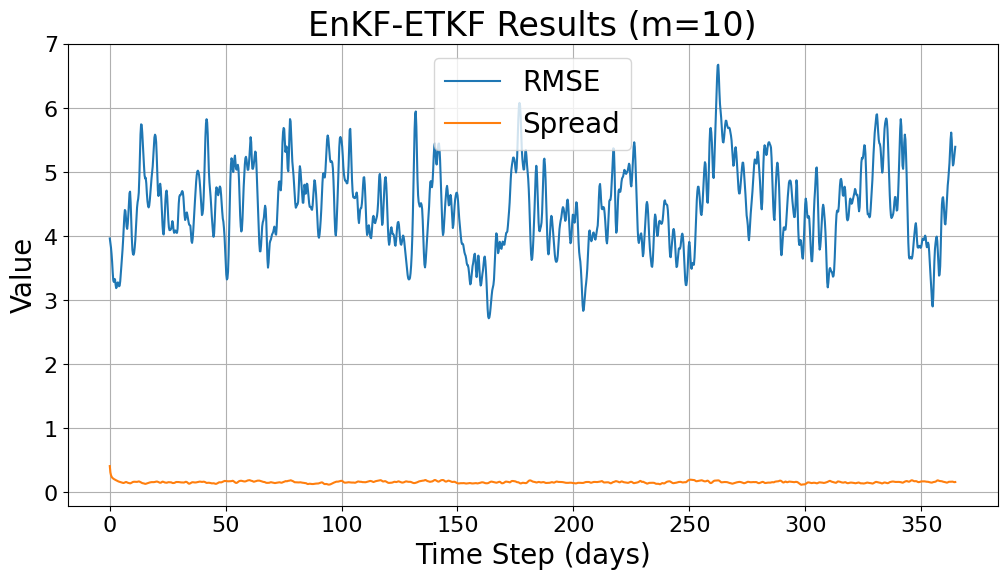

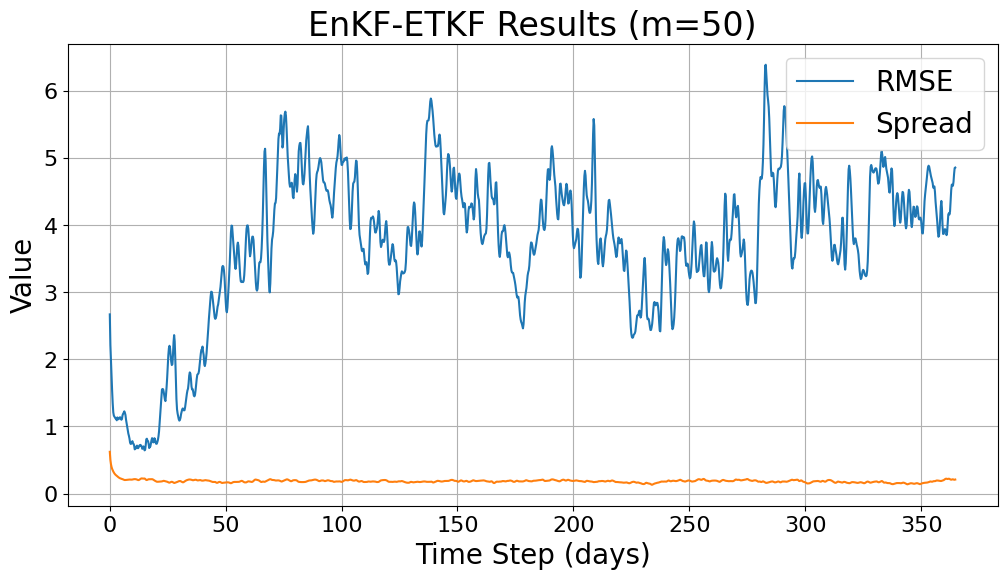

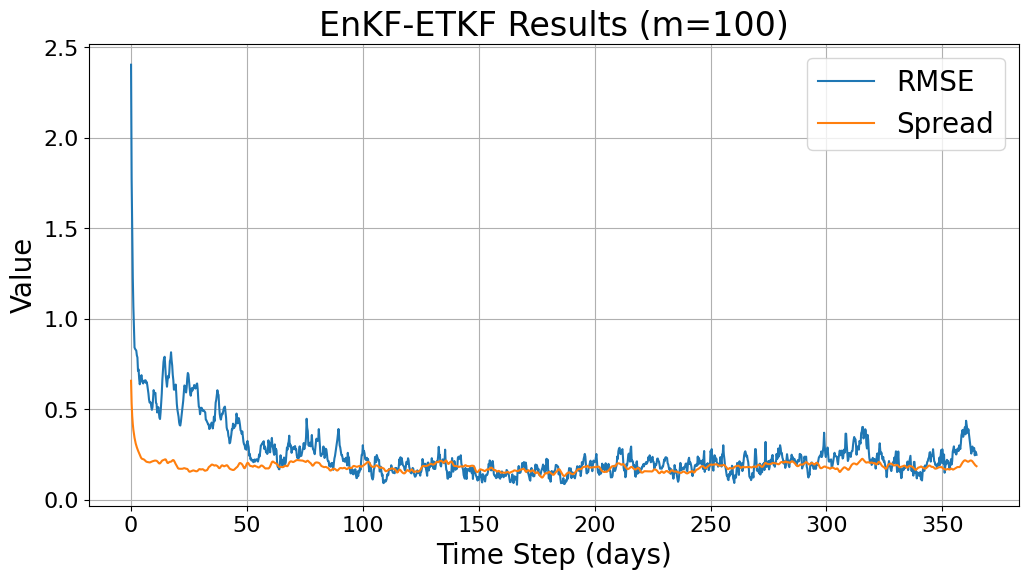

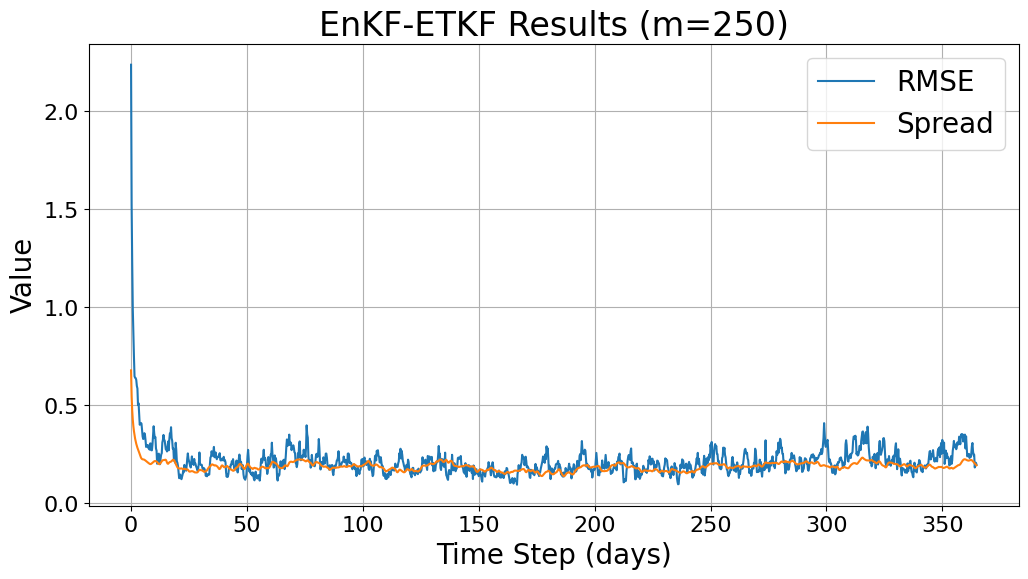

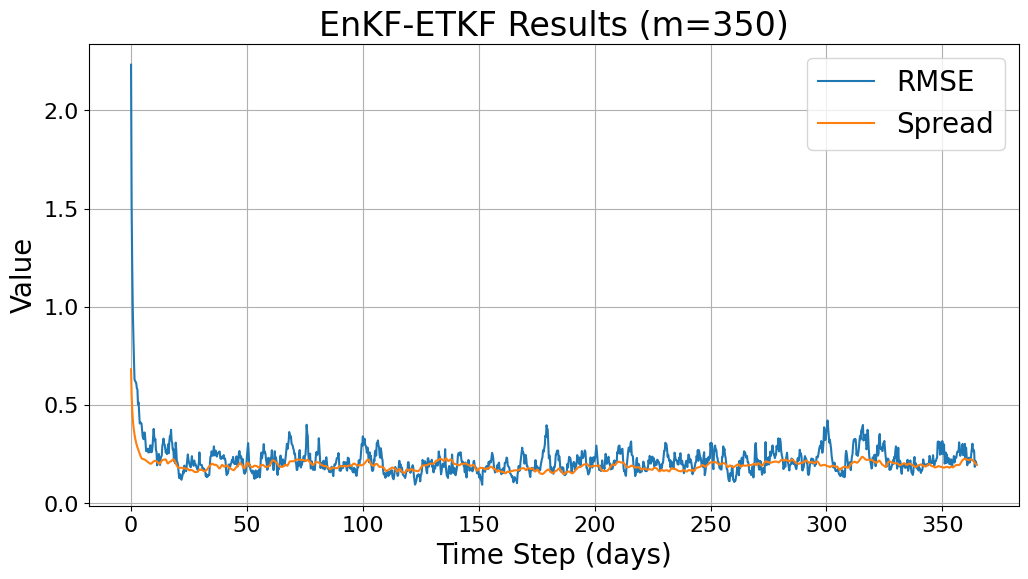

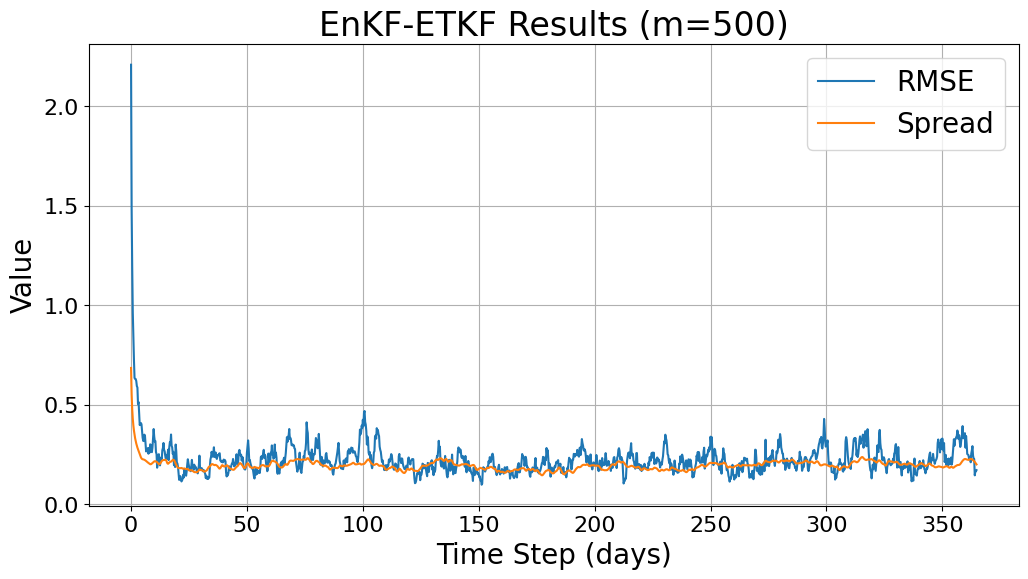

In [ ]:
# メンバー変数m=10,100,180,500の場合でスプレッドと真値とのRMSEを図示するコード
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# メンバー変数のサイズリスト
member_sizes = [10, 50, 100, 250, 350, 500]

# 結果の格納用辞書
results_dict = {}

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()

# 各メンバーサイズでEnKF-ETKFを実行
for m in member_sizes:
    enkf_ETKF = EnKF_ETKF(N=N, F=F, dt=dt, ensemble_size=m, obs_error_std=1.0)
    enkf_ETKF.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_ETKF.forecast()
        enkf_ETKF.analysis(observed_states[t])
        print(f'EnKF-ETKF with m={m}, time step {t} / {observed_states.shape[0]} completed.')
    rmse = enkf_ETKF.calculate_rmse(true_states)
    spread = enkf_ETKF.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[m] = {'rmse': rmse_list, 'spread': spread_list}
# 結果のプロット
days = np.arange(observed_states.shape[0]) * dt / step_day
for m in member_sizes:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[m]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[m]['spread'][0], label='Spread')
    plt.title(f'EnKF-ETKF Results (m={m})', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

## LETKF(Local Ensemble Transform Kalman Filter)

### 局所化

局所化とは、データ同化において、観測データが影響を与える範囲を制限する手法である。アンサンブルデータ同化ではメンバー数が少ないと統計的に無関係なはずの遠く離れた地点同士で偽の相関が生じることがある。これを防ぐために、局所化を行い、観測データが影響を与える範囲を限定することで、より正確なデータ同化を実現する。

#### PO法の場合

PO法において局所化する際はCovariance localizationを用いる。Covariance Localizationでは、アンサンブルから計算される誤差共分散行列に対して、距離に基づくGaspari-Cohn関数などのローカライゼーション関数を適用し、遠く離れた地点間の相関を減少させる。

In [5]:
# PO法で局所化を導入したEnKFを実装するクラス
class EnKF_PO_Localized:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.0, loc_radius=5):
        """
        EnKFをPO法で初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        inflation_factor: インフレーション係数
        loc_radius: 局所化半径
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.R = R if R is not None else np.eye(N, N) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # シード値を固定して再現性を確保
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def forecast(self):
        """
        アンサンブルの予報ステップを実行するメソッド
        """
        if self.ensemble is None:
            raise RuntimeError("initialize_ensemble を先に実行してください。")
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z
    
    def localization_matrix(self, loc_radius):
        """
        Gaspari-Cohn関数を用いて局所化行列を生成するメソッド
        loc_radius: 局所化の半径
        """
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                r = dist / (np.sqrt(10/3)*loc_radius)
                if r <= 1:
                    L[i, j] = 1 - (5/3)*r**2 + (5/8)*r**3 + (1/2)*r**4 - (1/4)*r**5
                elif r <= 2:
                    L[i, j] = (4 - 5*r + (5/3)*r**2 + (5/8)*r**3 - (1/2)*r**4 + (1/12)*r**5)
                else:
                    L[i, j] = 0
        return L


    def analysis(self, observation):
        """
        アンサンブルの解析ステップを実行するメソッド
        observation: 観測値の配列
        """
        Z = self.Z.copy()
        L = self.localization_matrix(loc_radius=self.loc_radius)
        K = L * (Z @ self.Y.T) @ np.linalg.inv(L * (self.Y @ self.Y.T) + self.R)
        for i in range(self.ensemble_size):
            perturbation = np.random.normal(0, self.obs_error_std, self.N)
            innovation = K @ (observation + perturbation - self.H @ self.ensemble[:,i])
            self.ensemble[:,i] += innovation
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z_analysis = ((self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1))
        P_analysis = Z_analysis @ Z_analysis.T
        self.P_analysis_list.append(P_analysis.copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    def calculate_rmse(self, true_states):
        """
        RMSEを計算するメソッド
        true_states: 真の状態の配列(形状: (time_steps, N))
        戻り値: 各時間ステップでのRMSEのリスト
        """
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
        
    def calculate_spread(self): 
        """
        スプレッドを計算するメソッド
        """
        # P_analysis_listから各時点のスプレッドを計算して返す
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list


Random steps for spinup: 1126
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 0 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 1 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 2 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 3 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 4 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 5 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 6 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 7 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 8 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%, time step 9 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=40, inflation=5.0%,

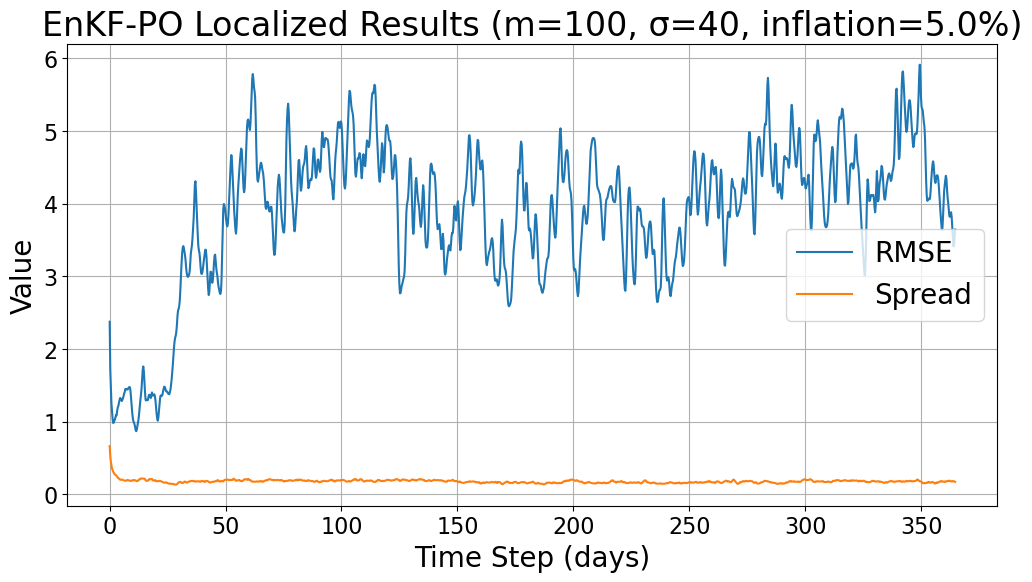

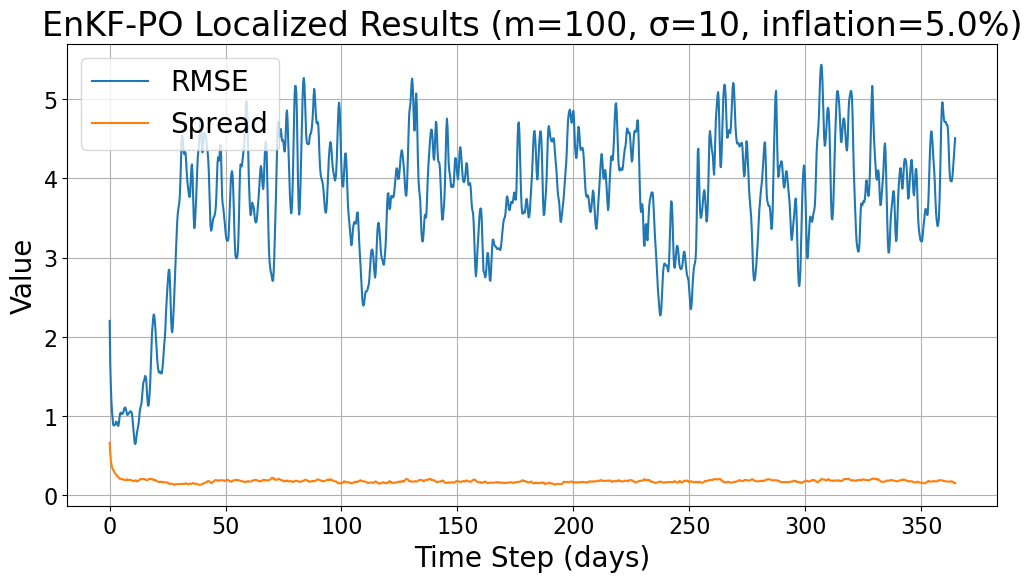

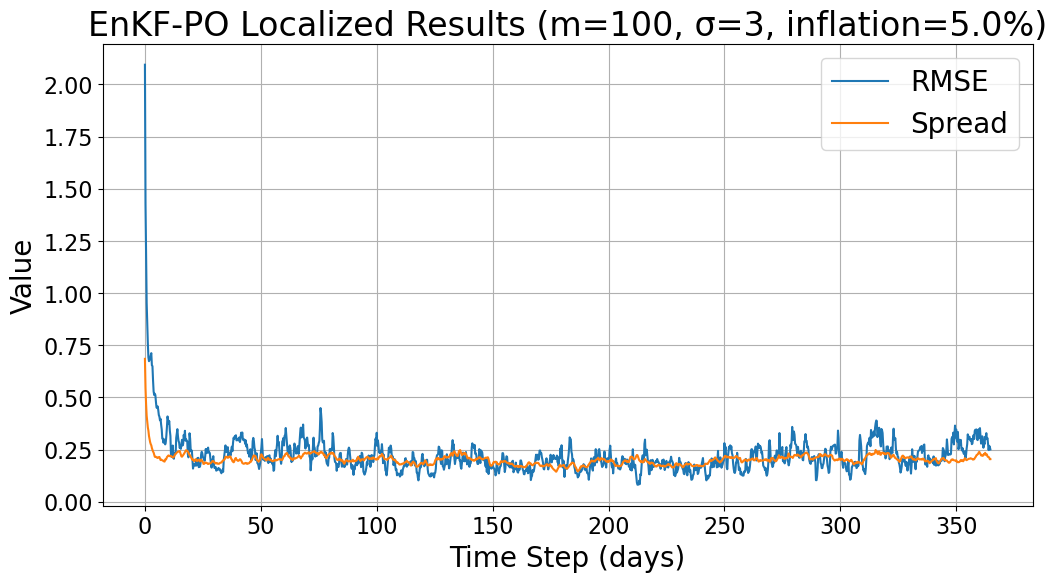

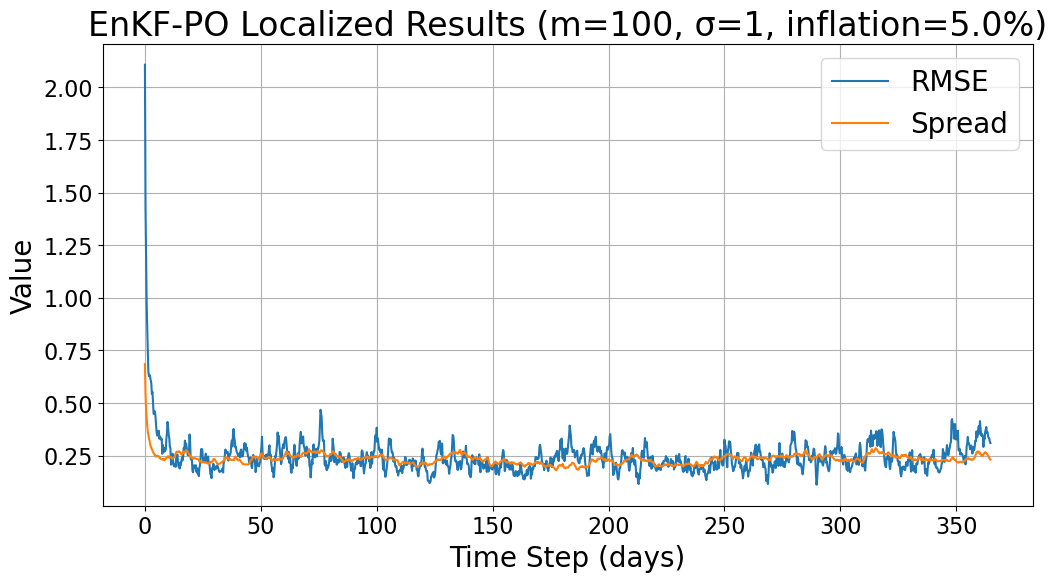

In [6]:
# メンバー数を40、inflation_factorを1.05で固定して、局所化半径を40,10,3,1で変化させた場合のスプレッドと真値とのRMSEを図示するコード
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 100  # メンバー数を固定
inflation_factor = 1.05  # インフレーションファクターを固定
loc_radius_list = [40, 10, 3, 1]  # 局所化半径のリスト
# 結果の格納用辞書
results_dict = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除
# 各局所化半径でEnKF-POを実行
for loc_radius in loc_radius_list:
    enkf_po_loc = EnKF_PO_Localized(N=N, F=F, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_po_loc.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_po_loc.forecast()
        enkf_po_loc.analysis(observed_states[t])
        print(f'EnKF-PO Localized with m={member_size}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%, time step {t} / {observed_states.shape[0]} completed.')
    rmse = enkf_po_loc.calculate_rmse(true_states)
    spread = enkf_po_loc.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[loc_radius] = {'rmse': rmse_list, 'spread': spread_list}
# 結果のプロット
days = np.arange(observed_states.shape[0]) * dt / step_day
for loc_radius in loc_radius_list:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[loc_radius]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[loc_radius]['spread'][0], label='Spread')
    plt.title(f'EnKF-PO Localized Results (m={member_size}, σ={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%)', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()


#### Serial EnSRFの場合

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Serial EnSRFを実装するクラス
class EnKF_SerialEnSRF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.0, loc_radius=5):
        """
        Serial EnSRFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        inflation_factor: インフレーション係数
        loc_radius: 局所化半径
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        # Rの次元を観測次元pに合わせる
        p = self.H.shape[0]
        self.R = R if R is not None else np.eye(p) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # シード値を固定して再現性を確保
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除
    
    def localization_matrix(self, loc_radius):
        """
        Gaspari-Cohn関数を用いて局所化行列を生成するメソッド
        loc_radius: 局所化の半径
        """
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                r = dist / (np.sqrt(10/3)*loc_radius)
                if r <= 1:
                    L[i, j] = 1 - (5/3)*r**2 + (5/8)*r**3 + (1/2)*r**4 - (1/4)*r**5
                elif r <= 2:
                    L[i, j] = (4 - 5*r + (5/3)*r**2 + (5/8)*r**3 - (1/2)*r**4 + (1/12)*r**5)
                else:
                    L[i, j] = 0
        return L

    def forecast(self):
        """
        アンサンブルの予報ステップを実行するメソッド
        """
        if self.ensemble is None:
            raise RuntimeError("initialize_ensemble を先に実行してください。")
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z

    def analysis(self, observation):
        """
        アンサンブルの解析ステップを実行するメソッド
        observation: 観測値の配列
        """
        # Hを用いて状態ベクトルから観測値を作成
        y_obs = self.H @ observation
        p = y_obs.shape[0] # 観測次元

        # forecastで計算されたアンサンブルの平均を取得
        x_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        
        # Inflationはループの前に一度だけ適用
        self.Z = self.Z * np.sqrt(self.inflation_factor)
        self.Y = self.H @ self.Z
        
        # 局所化行列Lを事前に計算
        L = self.localization_matrix(loc_radius=self.loc_radius)
        
        # Hから観測インデックスを取得
        obs_indices = np.where(self.H.any(axis=0))[0]
        
        for k in range(p):   
            # カルマンゲインの計算
            # Rは対角行列と仮定
            K = self.Z @ self.Y[k, :].T / (self.Y[k, :] @ self.Y[k, :].T + self.R[k, k])
            
            # k番目の観測に対応する状態変数のインデックスを取得
            obs_idx_k = np.where(self.H[k, :])[0][0]
            loc_vec = L[:, obs_idx_k]  # k番目の観測に対応する局所化ベクトル
            K_localized = loc_vec * K # 局所化の適用
            K_localized = K_localized[:, np.newaxis]
            
            # 平均の更新
            innovation = y_obs[k] - (self.H[k, :] @ x_mean)
            x_mean += K_localized * innovation 
            
            # アンサンブルの偏差の更新
            K_tilda = K_localized / (1 + np.sqrt(self.R[k, k] / (self.Y[k, :] @ self.Y[k, :].T + self.R[k, k])))
            self.Z -= K_tilda @ self.Y[k, :][np.newaxis, :]
            self.Y = self.H @ self.Z
        
        # アンサンブルの更新
        self.ensemble = x_mean + self.Z * np.sqrt(self.ensemble_size - 1) # アンサンブルの再構築
        
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z_analysis = ((self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)) # アンサンブル偏差の再計算
        P_analysis = Z_analysis @ Z_analysis.T # 解析誤差共分散行列の計算
        self.P_analysis_list.append(P_analysis.copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    
    def calculate_rmse(self, true_states):
        """
        RMSEを計算するメソッド
        true_states: 真の状態の配列(形状: (time_steps, N))
        戻り値: 各時間ステップでのRMSEのリスト
        """
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
    
    def calculate_spread(self):
        """
        スプレッドを計算するメソッド
        """
        # P_analysis_listから各時点のスプレッドを計算して返す
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list

In [12]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み
rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 10  # メンバー数を固定
# 結果の格納用辞書
results_dict = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# 1回のシミュレーションを実行するワーカー関数
def run_simulation(inflation_factor, loc_radius):
    # スピンアップ後の初期状態をコピーして使用
    initial_state = spinup.x.copy()
    
    enkf_serial_ensrf = EnKF_SerialEnSRF(N=N, F=F, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_serial_ensrf.initialize_ensemble(initial_state)
    
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_serial_ensrf.forecast()
        enkf_serial_ensrf.analysis(observed_states[t])
        print(f'EnKF-SerialEnSRF with m={member_size}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%, time step {t} / {observed_states.shape[0]} completed.')

    rmse = enkf_serial_ensrf.calculate_rmse(true_states)
    spread = enkf_serial_ensrf.calculate_spread()
    
    # 10日目から300日目までの平均RMSEを計算
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    print(f'Finished: inflation={inflation_factor}, loc_radius={loc_radius}, Avg RMSE={avg_rmse:.4f}')
    
    return inflation_factor, loc_radius, avg_rmse, [rmse], [spread]

# パラメータの全組み合わせを生成
param_combinations = list(itertools.product(inflation_factors, loc_radius_list))

# n_jobs=-1 は利用可能な全てのCPUコアを使用することを意味します
results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc) for inf, loc in param_combinations)

# 並列実行の結果を集約
inf_map = {val: i for i, val in enumerate(inflation_factors)}
loc_map = {val: j for j, val in enumerate(loc_radius_list)}

for inflation_factor, loc_radius, avg_rmse, rmse_list, spread_list in results:
    i = inf_map[inflation_factor]
    j = loc_map[loc_radius]
    rmse_matrix[i, j] = avg_rmse
    results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

# results_dictとrmse_matrixを別々に保存
# import pickle
# with open(f'enkf_serial_ensrf_results_dict_m{member_size}.pkl', 'wb') as f:
#     pickle.dump(results_dict, f)
with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}.npy', 'wb') as f:
    np.save(f, rmse_matrix)

Random steps for spinup: 1126


KeyboardInterrupt: 

RMSE Matrix:
[[3.72552756 0.32364466 0.24171157 0.22813806 0.2235076  0.21933023
  0.21245445 0.2131735  0.30217078 2.8775607  3.1726428  2.95664368
  3.477532   3.0825573  3.56682693 2.79439832 3.56024431 3.1943705
  3.81350077 3.62081822 3.3804545 ]
 [3.74829093 0.31496766 0.24216965 0.2308697  0.2217273  0.21237499
  0.20772988 0.20676406 0.20765671 0.21036873 0.2057898  0.74906913
  1.48143424 2.01776659 2.81347196 3.1061077  1.81832531 1.90520733
  2.31176536 2.21078339 2.52241027]
 [3.80668207 0.31626626 0.24750456 0.23523669 0.22753355 0.21774499
  0.21112891 0.21152473 0.21065099 0.2098136  0.20655794 0.21083192
  0.2282363  0.23534545 0.2649866  0.21284065 0.34447613 1.21920871
  0.59806908 0.21644197 1.59439993]
 [3.93563981 0.32069849 0.25515929 0.24295783 0.23402349 0.22728285
  0.22169755 0.21663718 0.2153174  0.21348552 0.21352953 0.21100759
  0.21150422 0.21152995 0.21223172 0.20946882 0.21386134 0.22027164
  0.5098117  0.21031792 0.22498954]
 [4.20666675 0.32532029 0.26

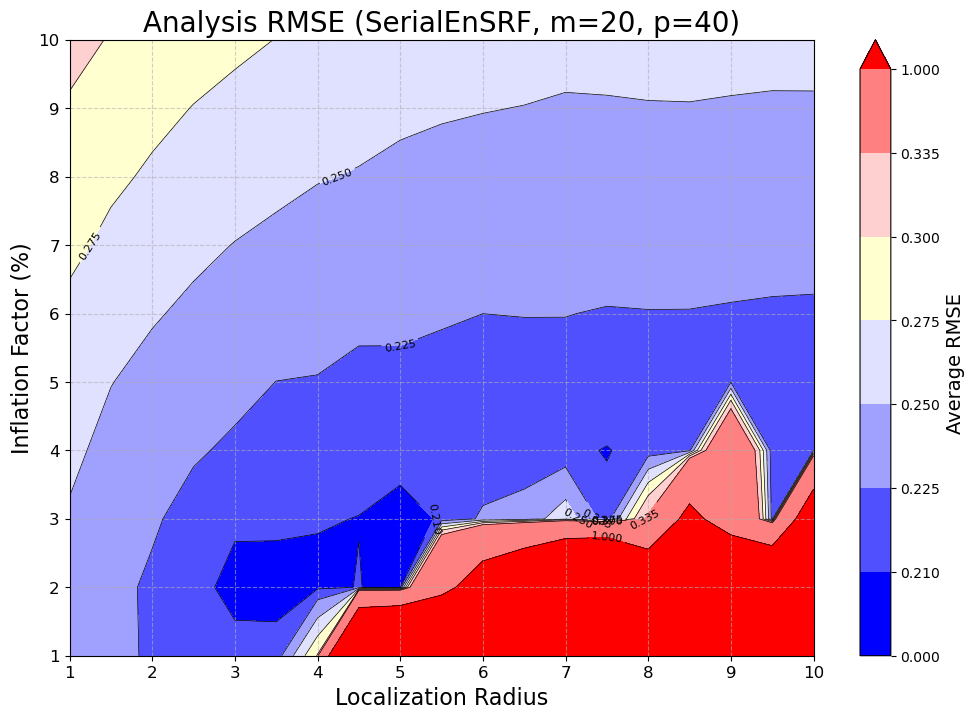

In [10]:
# データの読み込み
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 20  # メンバー数を固定
n_obs = 40  # 観測変数の数

with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.21, 0.225, 0.25, 0.275, 0.3, 0.335, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (SerialEnSRF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 観測地点数による比較

In [ ]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み
rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 20  # メンバー数を固定
num_obs = 20  # 観測変数の数
H = make_homogeneous_H(n=N, p=num_obs)
# 結果の格納用辞書
results_dict = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# 1回のシミュレーションを実行するワーカー関数
def run_simulation(inflation_factor, loc_radius):
    # スピンアップ後の初期状態をコピーして使用
    initial_state = spinup.x.copy()
    
    enkf_serial_ensrf = EnKF_SerialEnSRF(N=N, F=F, dt=dt, ensemble_size=member_size, obs_error_std=1.0, H=H, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_serial_ensrf.initialize_ensemble(initial_state)
    
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_serial_ensrf.forecast()
        enkf_serial_ensrf.analysis(observed_states[t])
        print(f'EnKF-SerialEnSRF with m={member_size}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%, time step {t} / {observed_states.shape[0]} completed.')

    rmse = enkf_serial_ensrf.calculate_rmse(true_states)
    spread = enkf_serial_ensrf.calculate_spread()
    
    # 10日目から300日目までの平均RMSEを計算
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    print(f'Finished: inflation={inflation_factor}, loc_radius={loc_radius}, Avg RMSE={avg_rmse:.4f}')
    
    return inflation_factor, loc_radius, avg_rmse, [rmse], [spread]

# パラメータの全組み合わせを生成
param_combinations = list(itertools.product(inflation_factors, loc_radius_list))

# n_jobs=-1 は利用可能な全てのCPUコアを使用することを意味します
results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc) for inf, loc in param_combinations)

# 並列実行の結果を集約
inf_map = {val: i for i, val in enumerate(inflation_factors)}
loc_map = {val: j for j, val in enumerate(loc_radius_list)}

for inflation_factor, loc_radius, avg_rmse, rmse_list, spread_list in results:
    i = inf_map[inflation_factor]
    j = loc_map[loc_radius]
    rmse_matrix[i, j] = avg_rmse
    results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

# results_dictとrmse_matrixを別々に保存
# import pickle
# with open(f'enkf_serial_ensrf_results_dict_m{member_size}_p{num_obs}homogeneous.pkl', 'wb') as f:
#     pickle.dump(results_dict, f)
with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{num_obs}homogeneous.npy', 'wb') as f:
    np.save(f, rmse_matrix)

Random steps for spinup: 1126


RMSE Matrix:
[[3.83907215 0.57275694 0.58573103 1.99624738 1.70564353 3.3652882
  3.95888827 3.89132444 4.13907774 4.47615839 4.35898975 4.49889086
  4.3386561  4.41973366 4.60188056 4.71208414 4.54291414 4.33290827
  4.50578618 4.77874838 4.56992869]
 [3.94950262 0.55178506 0.46845042 0.39923173 0.61136079 3.19417519
  2.84321629 3.73210499 3.57273163 4.14495228 4.08456429 4.17434063
  4.48515598 4.42016499 4.43103652 4.46068693 4.38011086 4.6246747
  4.44641407 4.72517541 4.55659913]
 [4.00872002 0.51559369 0.4241638  0.38370735 0.45121625 0.59290718
  2.8167398  3.6658822  3.56597482 3.95559824 4.24963608 4.09213467
  4.33429525 4.6614959  4.33196437 4.41753002 4.36749723 4.50673703
  4.29042176 4.54686451 4.53318856]
 [4.17046746 0.50322854 0.4326384  0.37760363 0.4961019  0.84670825
  0.70346326 0.66214951 3.14777926 3.51835735 4.2355935  4.22465268
  4.49938046 4.49873574 4.59550111 4.46391917 4.49025716 4.40193475
  4.68432777 4.53322304 4.81356895]
 [4.51262887 0.51842918 0.429

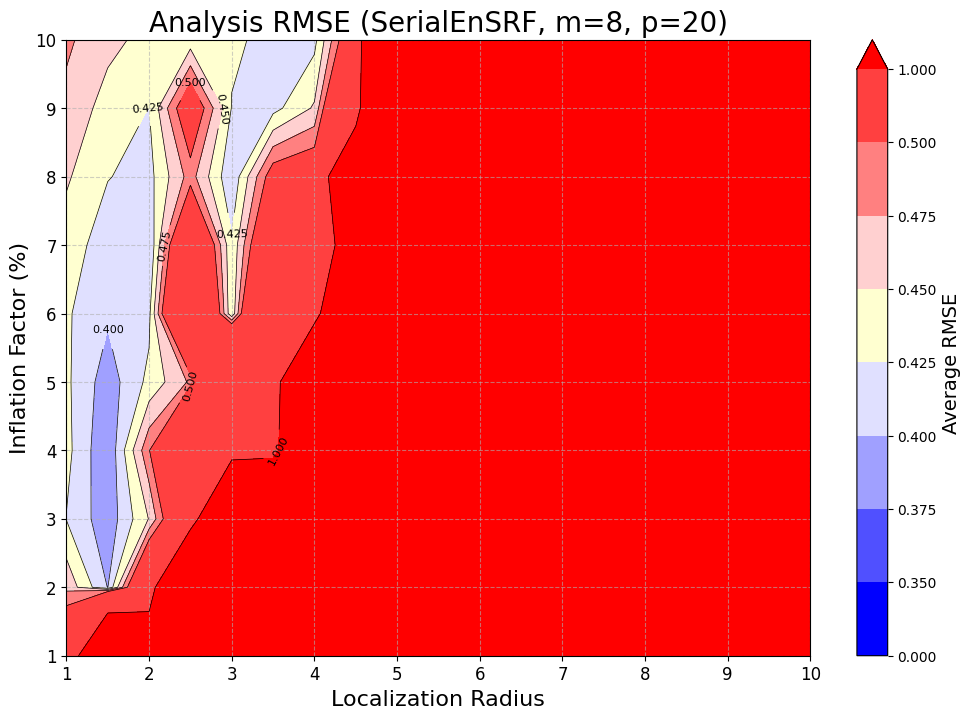

In [4]:
# データの読み込み
import pickle
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 8  # メンバー数を固定
n_obs = 20  # 観測変数の数

with open(f'enkf_serial_ensrf_results_dict_m{member_size}_p{n_obs}homogeneous.pkl', 'rb') as f:
    results_dict = pickle.load(f)
with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}homogeneous.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (SerialEnSRF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()